In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)


In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df = df.iloc[:,1:]

In [6]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,setosa
1,3.0,1.4,0.2,setosa
2,3.2,1.3,0.2,setosa
3,3.1,1.5,0.2,setosa
4,3.6,1.4,0.2,setosa


In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder = LabelEncoder()

In [10]:
df['species'] = encoder.fit_transform(df['species'])

In [11]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [20]:
df = df[df['species'] != 0][['sepal_width','petal_width','species']]


In [21]:
df.head()

,sepal_width,petal_width,species
50,3.2,1.4,1
51,3.2,1.5,1
52,3.1,1.5,1
53,2.3,1.3,1
54,2.8,1.5,1


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

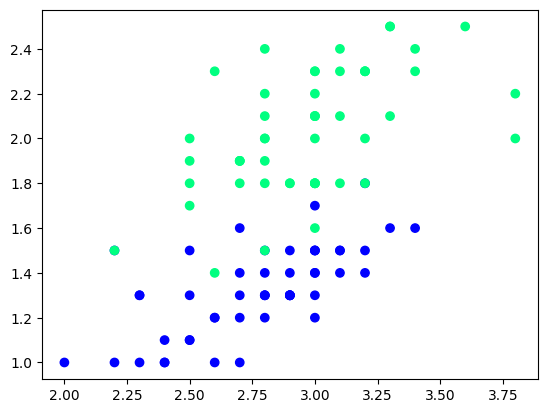

In [24]:
plt.scatter(df['sepal_width'],df['petal_width'],c=df['species'],cmap='winter')

In [25]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_width,species
70,3.2,1.8,1
68,2.2,1.5,1
94,2.7,1.3,1
104,3.0,2.2,2
102,3.0,2.1,2
72,2.5,1.5,1
93,2.3,1.0,1
64,2.9,1.3,1
60,2.0,1.0,1
99,2.8,1.3,1


In [26]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [27]:
df_train

,sepal_width,petal_width,species
103,2.9,1.8,2
144,3.3,2.5,2
56,3.3,1.6,1
135,3.0,2.3,2
148,3.4,2.3,2
78,2.9,1.5,1
59,2.7,1.4,1
75,3.0,1.4,1
146,2.5,1.9,2
53,2.3,1.3,1


In [28]:
df_val

,sepal_width,petal_width,species
92,2.6,1.2,1
133,2.8,1.5,2
85,3.4,1.6,1
121,2.8,2.0,2
128,2.8,2.1,2


In [29]:
df_test

,sepal_width,petal_width,species
136,3.4,2.4,2
98,2.5,1.1,1
104,3.0,2.2,2
72,2.5,1.5,1
84,3.0,1.5,1


In [30]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [31]:
y_test

array([1, 2, 1, 2, 2])

# Case 1 - Bagging

In [32]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_width,species
135,3.0,2.3,2
56,3.3,1.6,1
148,3.4,2.3,2
135,3.0,2.3,2
144,3.3,2.5,2
103,2.9,1.8,2
148,3.4,2.3,2
59,2.7,1.4,1


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [34]:
dt_bag1 = DecisionTreeClassifier()

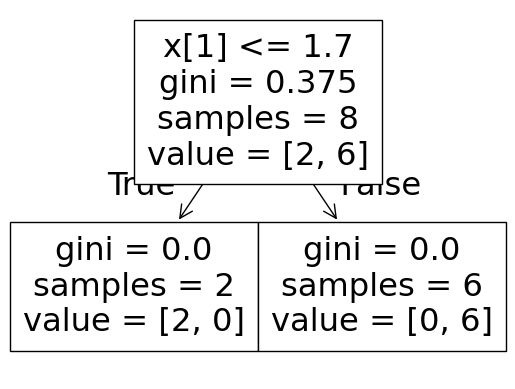

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


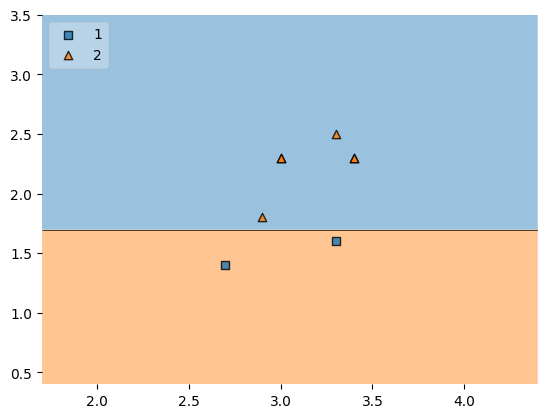

In [37]:
evaluate(dt_bag1,X,y)

In [38]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_width,species
135,3.0,2.3,2
78,2.9,1.5,1
53,2.3,1.3,1
103,2.9,1.8,2
146,2.5,1.9,2
148,3.4,2.3,2
144,3.3,2.5,2
75,3.0,1.4,1


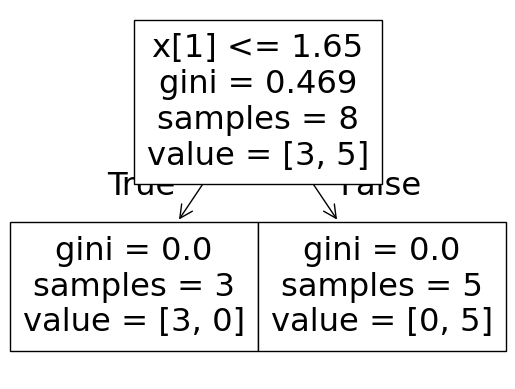

0.8


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


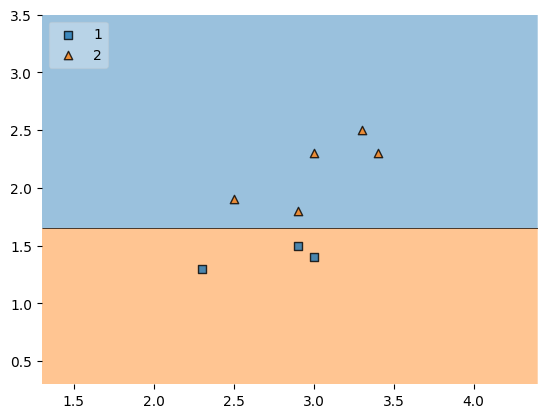

In [39]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [40]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_width,species
75,3.0,1.4,1
53,2.3,1.3,1
146,2.5,1.9,2
53,2.3,1.3,1
78,2.9,1.5,1
103,2.9,1.8,2
78,2.9,1.5,1
59,2.7,1.4,1


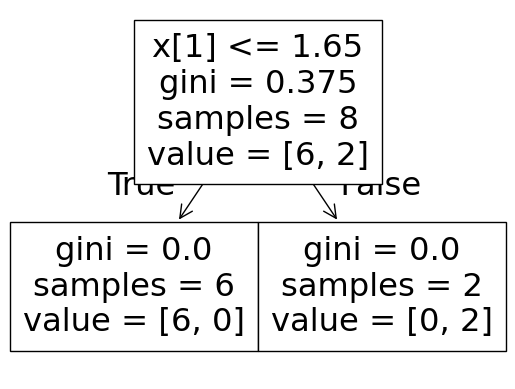

0.8


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


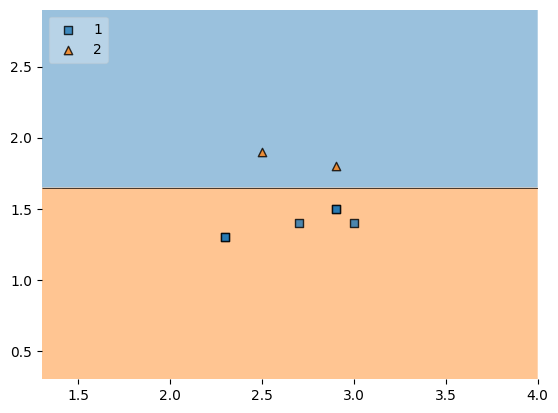

In [41]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [36]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [42]:
df_test

,sepal_width,petal_width,species
136,3.4,2.4,2
98,2.5,1.1,1
104,3.0,2.2,2
72,2.5,1.5,1
84,3.0,1.5,1


In [44]:
print("Predictor 1",dt_bag1.predict(np.array([2.5,1.1]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.5,1.1]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.5,1.1]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [45]:
# Row sampling without replacement
df_train

,sepal_width,petal_width,species
103,2.9,1.8,2
144,3.3,2.5,2
56,3.3,1.6,1
135,3.0,2.3,2
148,3.4,2.3,2
78,2.9,1.5,1
59,2.7,1.4,1
75,3.0,1.4,1
146,2.5,1.9,2
53,2.3,1.3,1


In [46]:
df_train.sample(8)

,sepal_width,petal_width,species
75,3.0,1.4,1
56,3.3,1.6,1
53,2.3,1.3,1
103,2.9,1.8,2
146,2.5,1.9,2
144,3.3,2.5,2
78,2.9,1.5,1
59,2.7,1.4,1


# Random Subspaces

In [48]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df1 = pd.read_csv(url)
df1 = df1.sample(10)

In [49]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
94,5.6,2.7,4.2,1.3,versicolor
7,5.0,3.4,1.5,0.2,setosa
66,5.6,3.0,4.5,1.5,versicolor
128,6.4,2.8,5.6,2.1,virginica
119,6.0,2.2,5.0,1.5,virginica
71,6.1,2.8,4.0,1.3,versicolor
115,6.4,3.2,5.3,2.3,virginica
72,6.3,2.5,4.9,1.5,versicolor
56,6.3,3.3,4.7,1.6,versicolor
13,4.3,3.0,1.1,0.1,setosa


In [54]:
df1.sample(2,replace=True,axis=1)

,sepal_width,petal_length
94,2.7,4.2
7,3.4,1.5
66,3.0,4.5
128,2.8,5.6
119,2.2,5.0
71,2.8,4.0
115,3.2,5.3
72,2.5,4.9
56,3.3,4.7
13,3.0,1.1


# Random Patches

In [55]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
94,5.6,2.7,4.2,1.3,versicolor
7,5.0,3.4,1.5,0.2,setosa
66,5.6,3.0,4.5,1.5,versicolor
128,6.4,2.8,5.6,2.1,virginica
119,6.0,2.2,5.0,1.5,virginica
71,6.1,2.8,4.0,1.3,versicolor
115,6.4,3.2,5.3,2.3,virginica
72,6.3,2.5,4.9,1.5,versicolor
56,6.3,3.3,4.7,1.6,versicolor
13,4.3,3.0,1.1,0.1,setosa


In [59]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_length,petal_length
66,5.6,4.5
72,6.3,4.9
128,6.4,5.6
72,6.3,4.9
119,6.0,5.0
115,6.4,5.3
66,5.6,4.5
7,5.0,1.5
